<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement Auto Encoder model on MINIST datase

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3384 - val_loss: 0.2713
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2677 - val_loss: 0.2653
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2648 - val_loss: 0.2639
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2631 - val_loss: 0.2622
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2600 - val_loss: 0.2574
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2561 - val_loss: 0.2543
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2528 - val_loss: 0.2506


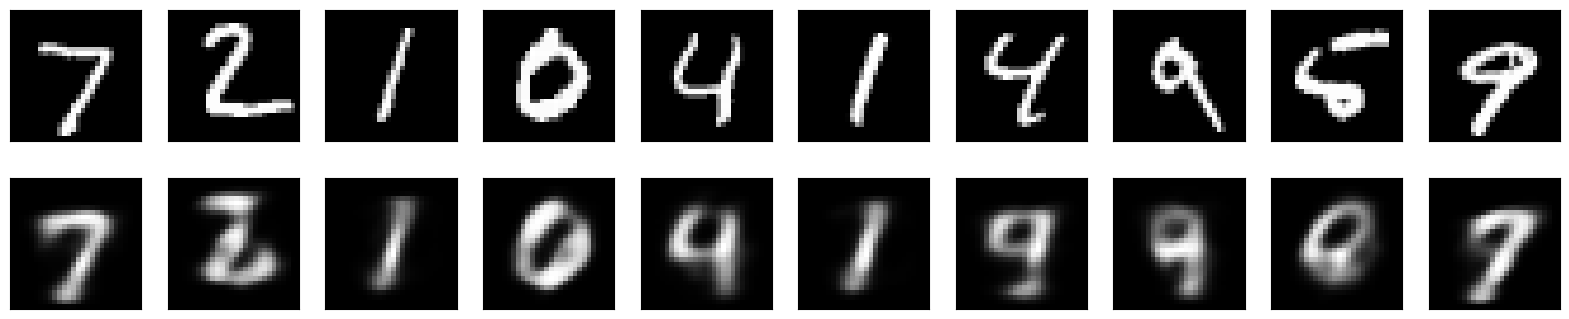

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


Training Autoencoder with encoding_dim = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 8)
Sample encoded vector: [0.8813677  2.124921   0.8267693  2.3696015  0.         0.48473305
 0.34531468 0.7298531 ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


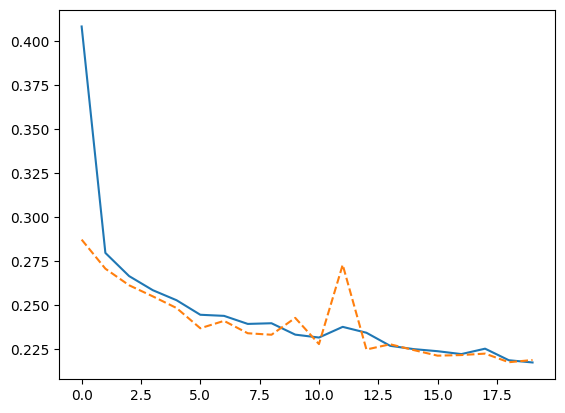

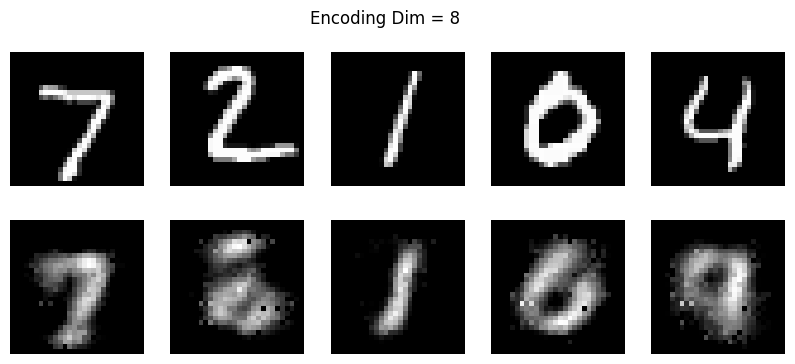


Training Autoencoder with encoding_dim = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 16)
Sample encoded vector: [1.3559004  0.         1.6269588  1.0621945  1.5787069  0.
 0.         0.64982206 1.1198462  1.518458  ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


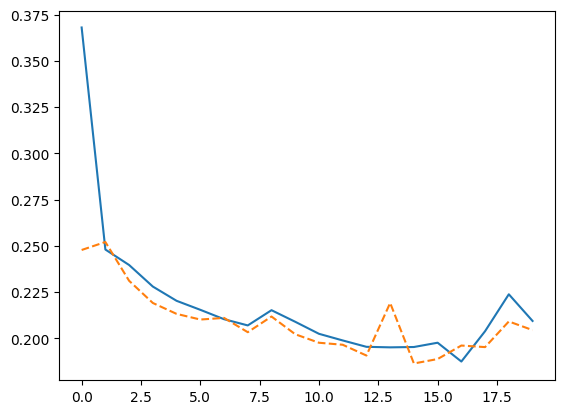

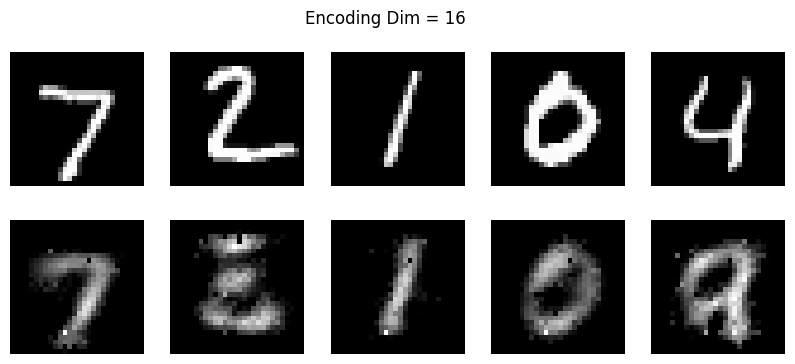


Training Autoencoder with encoding_dim = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 32)
Sample encoded vector: [0.         0.         0.92950517 0.         0.19963203 0.11545432
 3.0337148  0.47241443 1.3917905  0.96721834]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


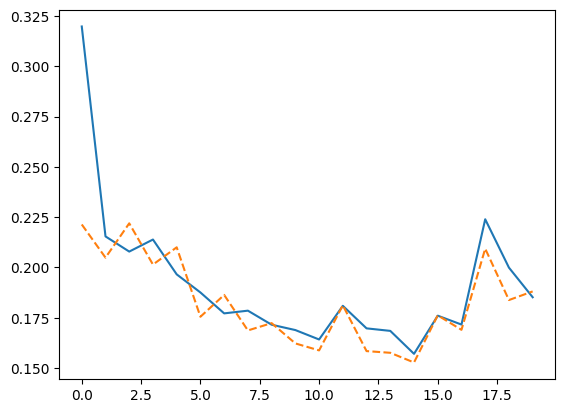

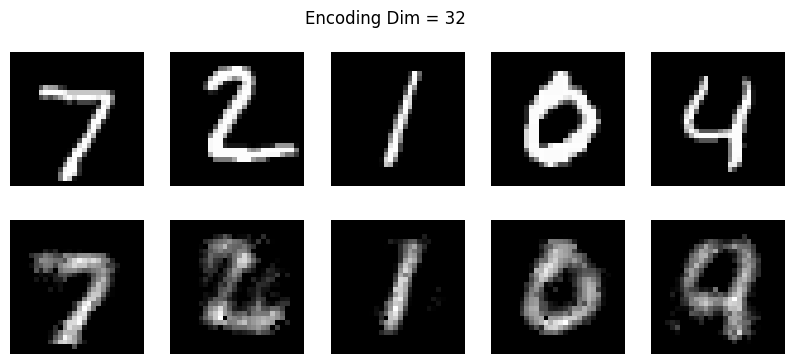


Training Autoencoder with encoding_dim = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 64)
Sample encoded vector: [0.        0.4418301 0.        0.        0.        0.        0.
 0.5947373 0.        0.       ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


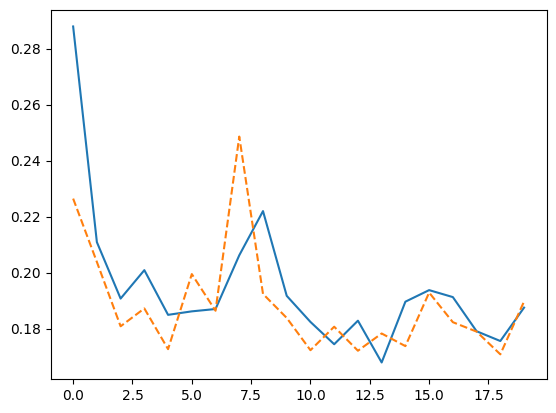

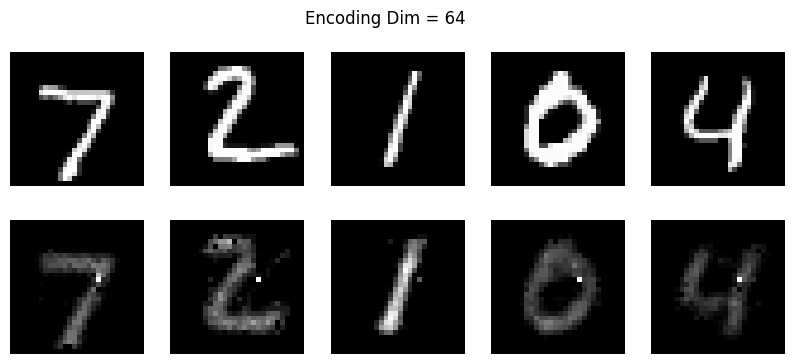


Training Autoencoder with encoding_dim = 128
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Encoded shape: (10000, 128)
Sample encoded vector: [0.         1.5328778  0.         0.         1.2536018  0.
 0.11769041 0.27029306 0.         0.        ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


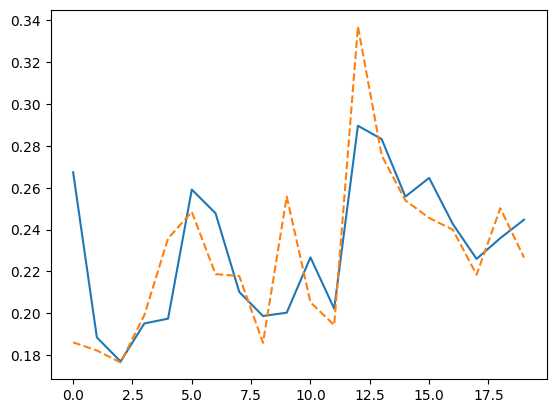

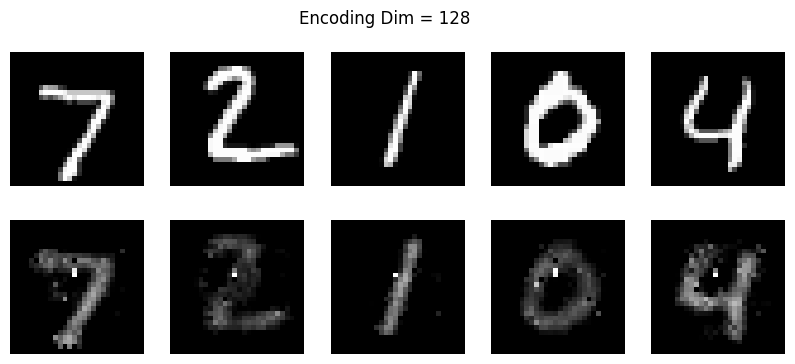


Final Validation Loss for each Encoding Dimension:
Encoding Dim: 8 --> Val Loss: 0.2185956984758377
Encoding Dim: 16 --> Val Loss: 0.20439688861370087
Encoding Dim: 32 --> Val Loss: 0.18807251751422882
Encoding Dim: 64 --> Val Loss: 0.18967178463935852
Encoding Dim: 128 --> Val Loss: 0.22657553851604462


/tmp/ipykernel_3537/1628556247.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


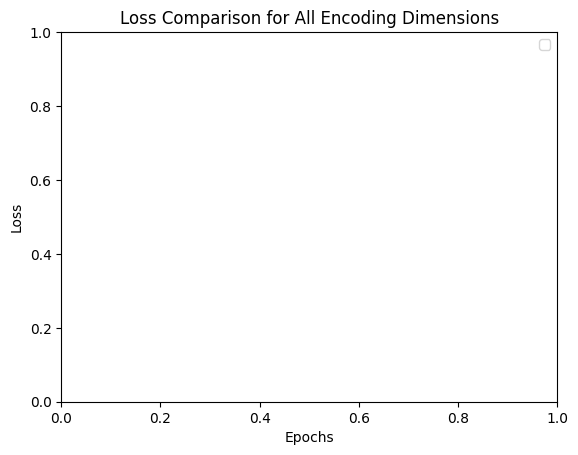

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Try Different Encoding Dimensions
encoding_dims = [8, 16, 32, 64, 128]
results = {}

for encoding_dim in encoding_dims:
    print(f"\nTraining Autoencoder with encoding_dim = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='relu')(encoded)

    # Autoencoder Model
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train
    history = autoencoder.fit(
        x_train, x_train,
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=0
    )

    # Save final validation loss
    final_loss = history.history['val_loss'][-1]
    results[encoding_dim] = final_loss

    # Plot Loss Curve
    plt.plot(history.history['loss'], label=f'Train {encoding_dim}')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'Val {encoding_dim}')

    # ----- Encoder Model -----
    encoder = Model(input_layer, encoded)
    encoded_imgs = encoder.predict(x_test)

    print("Encoded shape:", encoded_imgs.shape)
    print("Sample encoded vector:", encoded_imgs[0][:10])

    # ----- Decoder Model -----
    encoded_input = Input(shape=(encoding_dim,))
    decoder_layer = autoencoder.layers[-1]
    decoder = Model(encoded_input, decoder_layer(encoded_input))

    decoded_imgs = decoder.predict(encoded_imgs)

    # ----- Visualization -----
    n = 5
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.gray()
        ax.axis('off')

    plt.suptitle(f"Encoding Dim = {encoding_dim}")
    plt.show()

# Final Loss Comparison
print("\nFinal Validation Loss for each Encoding Dimension:")
for dim, loss in results.items():
    print(f"Encoding Dim: {dim} --> Val Loss: {loss}")

# Plot Combined Loss Graph
plt.title("Loss Comparison for All Encoding Dimensions")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6424 - mse: 0.0400 - val_loss: 0.6211 - val_mse: 0.0299
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6150 - mse: 0.0276 - val_loss: 0.6109 - val_mse: 0.0253
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6063 - mse: 0.0237 - val_loss: 0.6036 - val_mse: 0.0223
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6009 - mse: 0.0215 - val_loss: 0.5984 - val_mse: 0.0201
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5958 - mse: 0.0193 - val_loss: 0.5946 - val_mse: 0.0185
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5923 - mse: 0.0178 - val_loss: 0.5914 - val_mse: 0.0171
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5898 - mse: 0.0168 - val_loss: 0.5892 - val_mse: 0.0162
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5883 - mse: 0.0162 - val_loss: 0.5883 - val_mse: 0.0158
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - l

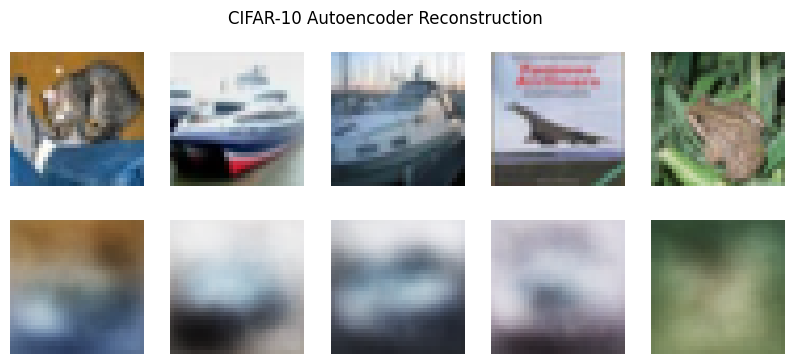

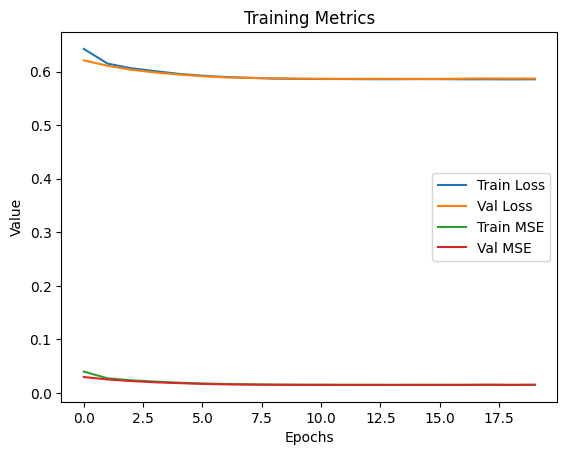

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# 1. Load CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Flatten images (32x32x3 → 3072)
X_train = X_train.reshape((len(X_train), 3072))
X_test = X_test.reshape((len(X_test), 3072))

# 2. Model Parameters
input_dim = 3072
encoding_dim = 128   # Start moderate

# 3. Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# 4. Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 5. Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 6. Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])

# 7. Train
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# ----------- Custom "Accuracy" Calculation -----------
decoded_imgs = autoencoder.predict(X_test)

# MSE
mse = np.mean(np.square(X_test - decoded_imgs))

# Pseudo Accuracy (just for intuition)
pseudo_accuracy = 1 - mse

print("\nFinal MSE:", mse)
print("Pseudo Accuracy:", pseudo_accuracy)

# 8. Predict
decoded_imgs = autoencoder.predict(X_test)

# 9. Reshape back to image
decoded_imgs = decoded_imgs.reshape((-1, 32, 32, 3))
X_test_imgs = X_test.reshape((-1, 32, 32, 3))

# 10. Visualization
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_imgs[i])
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.suptitle("CIFAR-10 Autoencoder Reconstruction")
plt.show()
# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

# Plot MSE
plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Val MSE')

plt.legend()
plt.title("Training Metrics")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.show()


🔥 Training with encoding_dim = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.6140797138214111
MSE: 0.02702215500175953
Pseudo Accuracy: 0.9729778170585632


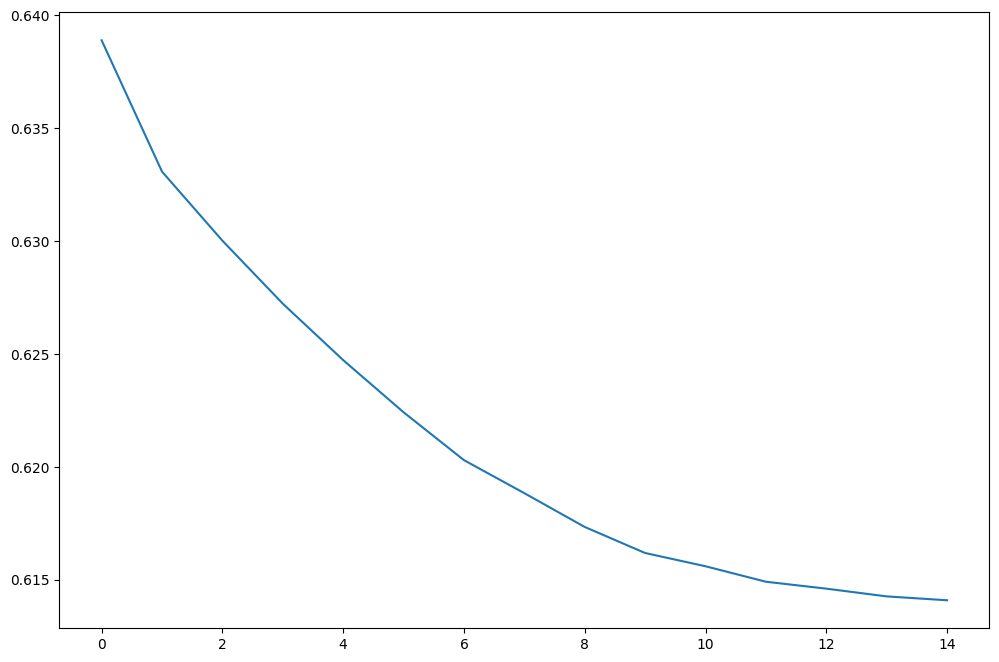

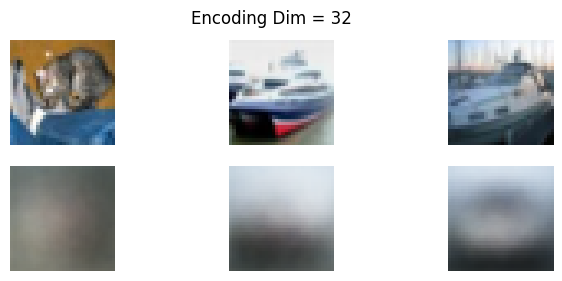


🔥 Training with encoding_dim = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Val Loss: 0.6008833050727844
MSE: 0.02126452513039112
Pseudo Accuracy: 0.9787354469299316


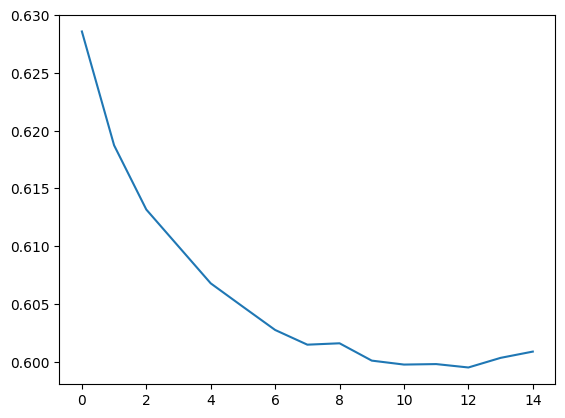

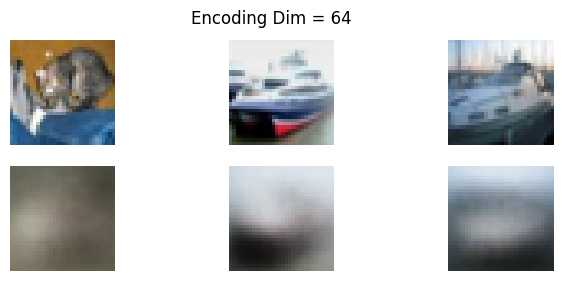


🔥 Training with encoding_dim = 128
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Val Loss: 0.5879700779914856
MSE: 0.015943871811032295
Pseudo Accuracy: 0.9840561151504517


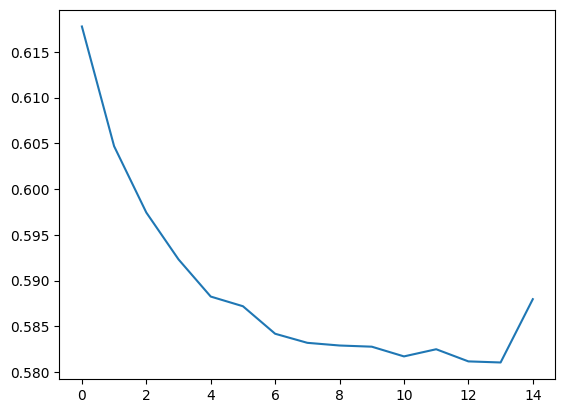

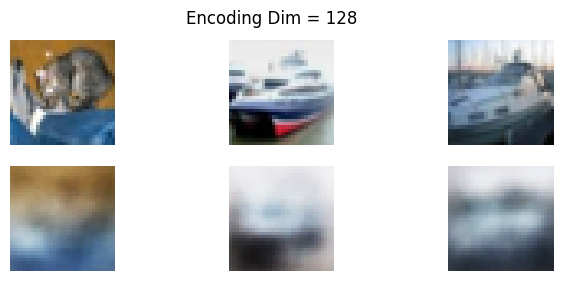


🔥 Training with encoding_dim = 256
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Val Loss: 0.5752802491188049
MSE: 0.010476247407495975
Pseudo Accuracy: 0.9895237684249878


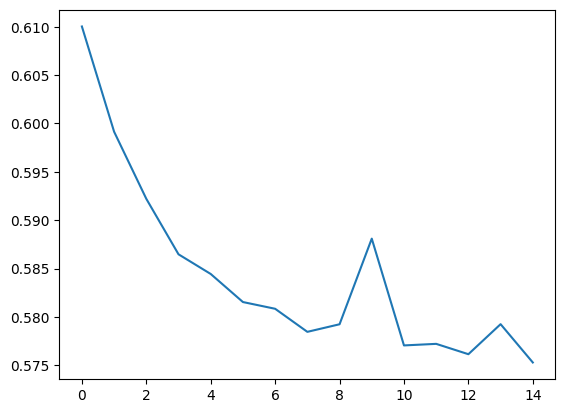

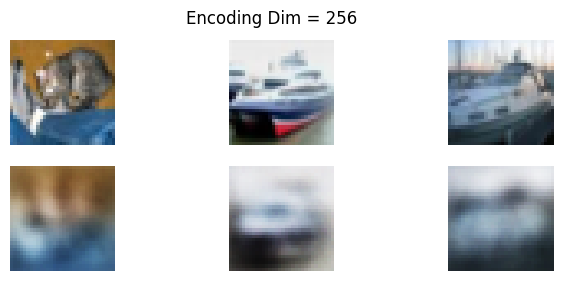


📊 Final Comparison:
Dim 32 → Loss: 0.6141, MSE: 0.0270, Acc: 0.9730
Dim 64 → Loss: 0.6009, MSE: 0.0213, Acc: 0.9787
Dim 128 → Loss: 0.5880, MSE: 0.0159, Acc: 0.9841
Dim 256 → Loss: 0.5753, MSE: 0.0105, Acc: 0.9895


/tmp/ipykernel_2528/2493620040.py:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


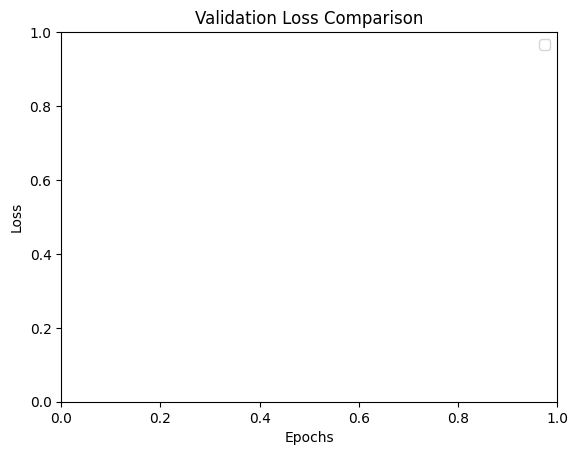

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Flatten
X_train = X_train.reshape((len(X_train), 3072))
X_test = X_test.reshape((len(X_test), 3072))

# Different encoding dimensions
encoding_dims = [32, 64, 128, 256]
results = {}

plt.figure(figsize=(12, 8))

for encoding_dim in encoding_dims:
    print(f"\n🔥 Training with encoding_dim = {encoding_dim}")

    # Model
    input_layer = Input(shape=(3072,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    decoded = Dense(3072, activation='sigmoid')(encoded)

    autoencoder = Model(input_layer, decoded)

    autoencoder.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['mse']
    )

    # Train
    history = autoencoder.fit(
        X_train, X_train,
        epochs=15,
        batch_size=256,
        shuffle=True,
        validation_data=(X_test, X_test),
        verbose=0
    )

    # Predict
    decoded_imgs = autoencoder.predict(X_test)

    # Metrics
    mse = np.mean(np.square(X_test - decoded_imgs))
    pseudo_acc = 1 - mse

    results[encoding_dim] = {
        "val_loss": history.history['val_loss'][-1],
        "mse": mse,
        "pseudo_acc": pseudo_acc
    }

    print(f"Val Loss: {results[encoding_dim]['val_loss']}")
    print(f"MSE: {mse}")
    print(f"Pseudo Accuracy: {pseudo_acc}")

    # Plot Loss Curve
    plt.plot(history.history['val_loss'], label=f"dim={encoding_dim}")

    # ---- Visualization ----
    decoded_imgs = decoded_imgs.reshape((-1, 32, 32, 3))
    X_test_imgs = X_test.reshape((-1, 32, 32, 3))

    n = 3
    plt.figure(figsize=(8, 3))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(X_test_imgs[i])
        plt.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.axis('off')

    plt.suptitle(f"Encoding Dim = {encoding_dim}")
    plt.show()

# Final comparison
print("\n📊 Final Comparison:")
for dim, res in results.items():
    print(f"Dim {dim} → Loss: {res['val_loss']:.4f}, MSE: {res['mse']:.4f}, Acc: {res['pseudo_acc']:.4f}")

# Plot combined loss
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.show()

🚀 STEP 3: Deep (Multi-Layer) Autoencoder

👉 Goal: Improve feature learning while still using Dense layers

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 0.6379 - mse: 0.0381 - val_loss: 0.6094 - val_mse: 0.0250
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6037 - mse: 0.0229 - val_loss: 0.6009 - val_mse: 0.0215
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5960 - mse: 0.0197 - val_loss: 0.5928 - val_mse: 0.0179
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5908 - mse: 0.0174 - val_loss: 0.5904 - val_mse: 0.0169
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.5876 - mse: 0.0161 - val_loss: 0.5879 - val_mse: 0.0159
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5857 - mse: 0.0153 - val_loss: 0.5885 - val_mse: 0.0160
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5842 - mse: 0.0147 - val_loss: 0.5852 - val_mse: 0.0146
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5826 - mse: 0.0140 - val_loss: 0.5825 - val_mse: 0.0136
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - l

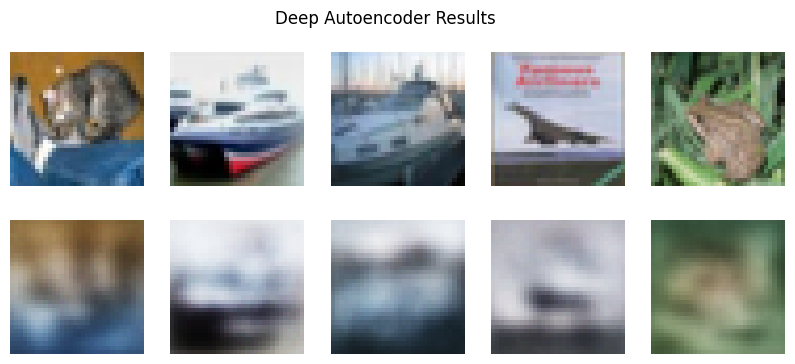

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Load CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Flatten
X_train = X_train.reshape((len(X_train), 3072))
X_test = X_test.reshape((len(X_test), 3072))

# Model
input_layer = Input(shape=(3072,))

# Encoder (Deep)
encoded = Dense(512, activation='relu')(input_layer)
encoded = Dense(256, activation='relu')(encoded)
encoded = Dense(128, activation='relu')(encoded)

# Decoder (Mirror)
decoded = Dense(256, activation='relu')(encoded)
decoded = Dense(512, activation='relu')(decoded)
decoded = Dense(3072, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])

# Train
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predict
decoded_imgs = autoencoder.predict(X_test)

# Metrics
mse = np.mean(np.square(X_test - decoded_imgs))
pseudo_acc = 1 - mse

print("\nDeep AE MSE:", mse)
print("Deep AE Accuracy:", pseudo_acc)

# Reshape
decoded_imgs = decoded_imgs.reshape((-1, 32, 32, 3))
X_test_imgs = X_test.reshape((-1, 32, 32, 3))

# Visualize
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test_imgs[i])
    plt.axis('off')

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.suptitle("Deep Autoencoder Results")
plt.show()

STEP 4: Convolutional Autoencoder (REAL UPGRADE)

Now we stop playing and start doing actual deep learning.

👉 This model:

Understands spatial structure
Preserves edges
Produces sharper images


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.5750 - mse: 0.0109 - val_loss: 0.5628 - val_mse: 0.0057
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5607 - mse: 0.0052 - val_loss: 0.5601 - val_mse: 0.0046
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5585 - mse: 0.0044 - val_loss: 0.5596 - val_mse: 0.0044
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5575 - mse: 0.0041 - val_loss: 0.5581 - val_mse: 0.0039
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5569 - mse: 0.0038 - val_loss: 0.5572 - val_mse: 0.0036
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5565 - mse: 0.0037 - val_loss: 0.5568 - val_mse: 0.0034
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5560 - mse: 0.0035 - val_loss: 0.5568 - val_mse: 0.0034
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.5556 - mse: 0.0033 - val_loss: 0.5561 - val_mse: 0.0032
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms

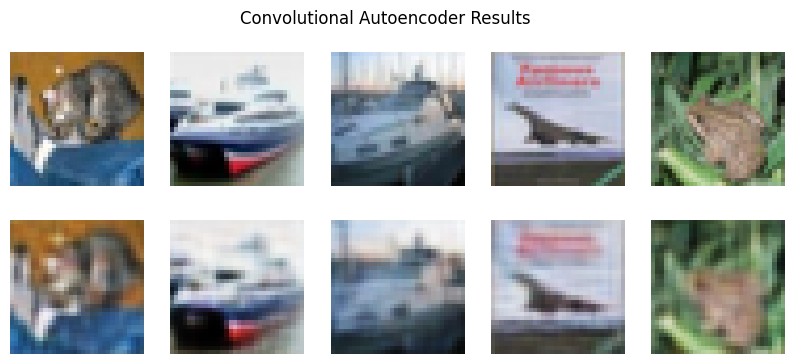

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

# Load CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

# Model
input_img = Input(shape=(32, 32, 3))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])

# Train
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predict
decoded_imgs = autoencoder.predict(X_test)

# Metrics
mse = np.mean(np.square(X_test - decoded_imgs))
pseudo_acc = 1 - mse

print("\nConv AE MSE:", mse)
print("Conv AE Accuracy:", pseudo_acc)

# Visualize
n = 5
plt.figure(figsize=(10, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.axis('off')

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.suptitle("Convolutional Autoencoder Results")
plt.show()